In [2]:
from typing import *
from langgraph.graph import StateGraph, START, END


In [12]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    operation1 : str
    operation2 : str
    result : int

In [13]:
def adderNode(state : AgentState) -> AgentState:
    """
    This node adds two numbers
    """
    state["result"] = state["number1"] + state["number2"]
    return state

def adderNode1(state : AgentState) -> AgentState:
    """
    This node adds two numbers
    """
    state["result"] = state["number1"] + state["number2"]
    return state
    
def subtractNode(state : AgentState) -> AgentState:
    """
    This node subtracts two numbers
    """
    state["result"] = state["number1"] - state["number2"]
    return state

def subtractNode1(state : AgentState) -> AgentState:
    """
    This node subtracts two numbers
    """
    state["result"] = state["number1"] - state["number2"]
    return state



def decisionNode(state : AgentState) -> AgentState:
    """
    This node decides the operation to be performed.
    We need to return the edge name as a string, instead of the node name. 
    """
    if state["operation1"] == "+":
        return "additionEdge"
    elif state["operation1"] == "-":
        return "subtractionEdge"
    else:
        raise ValueError(f"Invalid operation: {state['operation']}")

def decisionNode2(state : AgentState) -> AgentState:
    """
    This node decides the operation to be performed.
    We need to return the edge name as a string, instead of the node name. 
    """
    if state["operation2"] == "+":
        return "additionEdge1"
    elif state["operation2"] == "-":
        return "subtractionEdge1"
    else:
        raise ValueError(f"Invalid operation: {state['operation']}")


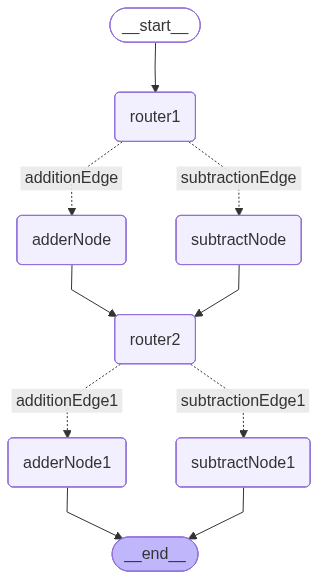

In [14]:
graph = StateGraph(AgentState)

graph.add_node("adderNode", adderNode)
graph.add_node("subtractNode", subtractNode)
graph.add_node("router1", lambda state:state)
graph.add_node("router2", lambda state:state)
graph.add_node("adderNode1", adderNode1)
graph.add_node("subtractNode1", subtractNode1)

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decisionNode,
    {   # Edge name : Node name
        "additionEdge" : "adderNode",
        "subtractionEdge" : "subtractNode"
    }
)
graph.add_conditional_edges(
    "router2",
    decisionNode2,
    {
        "additionEdge1" : "adderNode1",
        "subtractionEdge1" : "subtractNode1"
    }
)

graph.add_edge("adderNode", "router2")
graph.add_edge("subtractNode", "router2")

graph.add_edge("adderNode1", END)
graph.add_edge("subtractNode1", END)

graph.compile()


In [15]:
app = graph.compile()

agentstate1 = AgentState(number1=1, number2=2, operation1="+", operation2="+")
agentstate2 = AgentState(number1=1, number2=2, operation1="+", operation2="-")
agentstate3 = AgentState(number1=1, number2=2, operation1="-", operation2="+")
agentstate4 = AgentState(number1=1, number2=2, operation1="-", operation2="-")


print(app.invoke(agentstate1))
print(app.invoke(agentstate2))
print(app.invoke(agentstate3))
print(app.invoke(agentstate4))

{'number1': 1, 'number2': 2, 'operation1': '+', 'operation2': '+', 'result': 3}
{'number1': 1, 'number2': 2, 'operation1': '+', 'operation2': '-', 'result': -1}
{'number1': 1, 'number2': 2, 'operation1': '-', 'operation2': '+', 'result': 3}
{'number1': 1, 'number2': 2, 'operation1': '-', 'operation2': '-', 'result': -1}
